<h1 style="text-align: center;">Comparative Study — Multi-Class Wine Quality Classification</h1>

<h2>Section 1 — Problem Statement + Data Description</h2>
<h3>Problem Statement</h3>

You are given two tabular datasets containing lab-measured properties of wines. Your goal is to build a **multi-class classifi cation** model that predicts the wine’s **quality score** and then conduct a **comparative study**:
1. **Red vs White dataset**: Which dataset is easier to predict and why?
2. **Model vs Model**: Which model performs better on each dataset and why?
3. **Class-level difficulty**: Which quality scores are hardest to predict?
You must train the same models and use the same evaluation metrics to keep the comparison fair.
<h3>Data Description</h3>

**What one row represents**
Each row is one wine sample with measured chemical/physical properties.

**Target column**
- **quality**: an integer quality rating assigned to the wine.
- For this assignment, treat each unique value of quality as a separate class (multi-class classifi cation).

**Feature columns (all numeric)**
These are common wine chemistry measurements:
- **fixed acidity**: stable acids in wine
- **volatile acidity**: acetic acid (high values can reduce quality)
- **citric acid**: adds freshness
- **residual sugar**: sugar left after fermentation
- **chlorides**: salt content
- **free sulfur dioxide / total sulfur dioxide**: preservatives (SO₂ levels)
- **density**: related to alcohol and sugar
- **pH**: acidity level
- **sulphates**: stability/preservation
- **alcohol**: alcohol percentage

**What to expect in this dataset**
- **Class imbalance**: some quality scores appear much more frequently than others.
- **Overlapping classes**: quality levels like 5 and 6 may have similar feature values,
making them harder to separate.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



<h2>Task 1 — Load & Inspect the Data (Red + White)</h2>

**Instructions**
1. Load both CSV files using sep=";".
2. Print for each dataset:
   - shape (rows, cols)
   - first 5 rows
   - column list
3. Verify the target column quality exists.

**Deliverables**
- Output showing both datasets loaded correctly.
- 2–3 lines confirming the target column and number of features.

In [2]:
df_wine_red = pd.read_csv(r"dataset/winequality-red.csv", sep = ";")
df_wine_white = pd.read_csv(r"dataset/winequality-white.csv", sep = ";")

In [3]:
print("Shape of Red wine dataset : ",df_wine_red.shape)
print("Shape of White wine dataset : ",df_wine_white.shape)

Shape of Red wine dataset :  (1599, 12)
Shape of White wine dataset :  (4898, 12)


In [4]:
print("--"*50)
print("Red Wine Dataset First Five Observations".rjust(60))
print("--"*50)
print(df_wine_red.head(5))

print("--"*50)
print("White Wine Dataset First Five Observations".rjust(60))
print("--"*50)
print(df_wine_white.head(5))

----------------------------------------------------------------------------------------------------
                    Red Wine Dataset First Five Observations
----------------------------------------------------------------------------------------------------
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0  

In [5]:
pd.DataFrame(df_wine_red.columns, columns = ["FeatureNames"])

,FeatureNames
0,fixed acidity
1,volatile acidity
2,citric acid
3,residual sugar
4,chlorides
5,free sulfur dioxide
6,total sulfur dioxide
7,density
8,pH
9,sulphates


In [6]:
pd.DataFrame(df_wine_white.columns, columns = ["FeatureNames"])

,FeatureNames
0,fixed acidity
1,volatile acidity
2,citric acid
3,residual sugar
4,chlorides
5,free sulfur dioxide
6,total sulfur dioxide
7,density
8,pH
9,sulphates


In [7]:
df_wine_red["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [8]:
df_wine_white["quality"].unique()

array([6, 5, 7, 8, 4, 3, 9])

The target column "quality" exists and has 6 unique values for red wine dataset and 7 unique values for white wine dataset.

<h2>Task 2 — Data Quality Checks + Class</h2>
<h3>Distribution (Comparative)</h3>

**Instructions (do for red and white separately)**
1. Check missing values per column.
2. Check duplicates.
3. Show quality class distribution:
    - counts
    - percentages
4. Plot a bar chart of quality counts.

**Comparative Questions (answer in 4–6 lines)**
- Which dataset is more imbalanced?
- Which quality classes are rare?
- Why might rare classes be harder to predict?

**Deliverables**
- Missing values + duplicates output for both datasets
- 2 bar charts (red + white)
- Written comparison answers

In [9]:
df_wine_red.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
df_wine_white.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [11]:
df_wine_red.duplicated().sum()

np.int64(240)

In [12]:
df_wine_white.duplicated().sum()

np.int64(937)

In [13]:
df_wine_red.drop_duplicates(inplace = True)

In [14]:
df_wine_white.drop_duplicates(inplace = True)

In [15]:
df1 = df_wine_red["quality"].value_counts(ascending = False).to_frame(name = 'Count')
df1.assign(Percentages = np.round(df1['Count']/df1['Count'].sum(),2))

,Count,Percentages
quality,,
5,577,0.42
6,535,0.39
7,167,0.12
4,53,0.04
8,17,0.01
3,10,0.01


In [16]:
df2 = df_wine_white["quality"].value_counts(ascending = False).to_frame(name = 'Count')
df2.assign(Percentages = np.round(df2['Count']/df2['Count'].sum(),2))

,Count,Percentages
quality,,
6,1788,0.45
5,1175,0.30
7,689,0.17
4,153,0.04
8,131,0.03
3,20,0.01
9,5,0.00


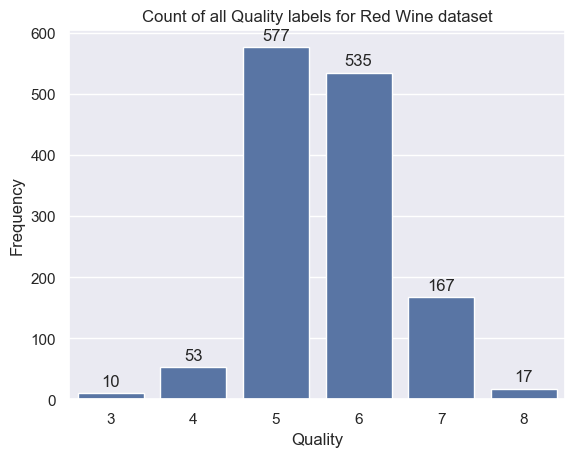

In [17]:
sns.set_theme()
plt.figure()
ax = sns.countplot(data = df_wine_red, x = "quality")
for container in  ax.containers:
    ax.bar_label(container, fmt = "{:,.0f}", padding = 3)
plt.xlabel("Quality")
plt.ylabel('Frequency')
plt.title("Count of all Quality labels for Red Wine dataset")
plt.show()

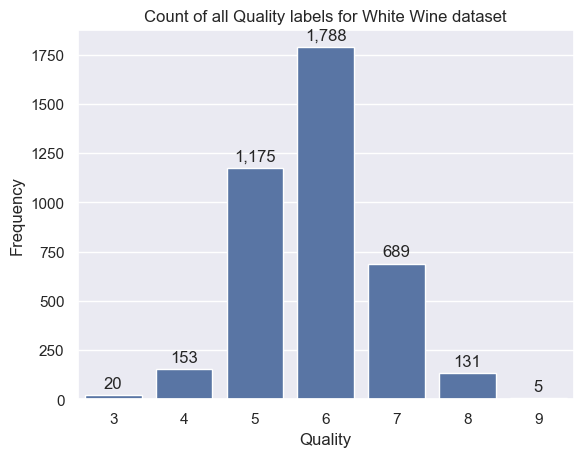

In [18]:
plt.figure()
ax = sns.countplot(data = df_wine_white, x = "quality")
for container in  ax.containers:
    ax.bar_label(container, fmt = "{:,.0f}", padding = 3)
plt.xlabel("Quality")
plt.ylabel('Frequency')
plt.title("Count of all Quality labels for White Wine dataset")
plt.show()

**Which dataset is more imbalanced?**

Comparatively, the Red Wine dataset is more balanced than the White Wine dataset for the following reasons:
1. The variance of White Wine Dataset is considerably more than the Red Wine Dataset
2. The Range of the White Wine dataset is almost 3 times that of the Red wine dataset.
3. The White dataset has an additional label 9 with only 5 corresponding observations apart from all the labels comprised by red wine dataset. This additional label with low observations add to the imbalance of the dataset

In [19]:
df1['Count'].var(), df2['Count'].var()

(68485.5, 475320.80952380947)

In [20]:
df1['Count'].max() - df1['Count'].min(), df2['Count'].max() - df2['Count'].min()

(567, 1783)

**Which quality classes are rare?**

The rare quality classes are {3,4,8} for Red wine dataset and {3,4,8,9} for White Wine dataset

**Why might rare classes be harder to predict?**

There are several reasons that makes rare classes harder to predict which are as follows:
1. Accuracy paradox: In white wine dataset quality class 9 corresponds to only 5 observations. If we do a stratified 70% train and 30% test split, we will get only 3 observations in the train dataset and 2 in the test dataset. If if the model fails to classify these observations, it will still yield high accuracy.
2. Lack of sufficient patterns: Since the model doesn't have a diverse set of obseervations for rare classes, calculating their threshold that would distinguish them from other classes/labels becomes difficult.
3. Shifted Decision Boundary: The majority classes will shift the decision boudnary closer to the minority classes yeilding very many false negatives
4. Overfitting to noise: If force the model to learn these rare examples, then  it might lead to overfitting. 

<h2>Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)</h2>

**Instructions (do for both datasets)**
1. Create:
    - X = all columns except quality
    - y = quality
2. Train-test split with:
    - test_size=0.2
    - random_state=42
    - stratify=y

**Deliverables**
- Train/test shapes for red and white
- 1–2 lines confirming stratification preserved similar class distribution

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_white = df_wine_white.iloc[:,0:11]
X_red = df_wine_red.iloc[:,0:11]

In [23]:
y_white = df_wine_white.iloc[:,11]
y_red = df_wine_red.iloc[:,11]

In [24]:
X_train_white, X_test_white,  y_train_white, y_test_white = train_test_split(X_white, y_white, 
                                                                        test_size = 0.2, 
                                                                            random_state = 42, 
                                                                            stratify = y_white )

In [25]:
X_train_white.size, X_test_white.size, y_train_white.size, y_test_white.size

(34848, 8723, 3168, 793)

In [26]:
X_train_red, X_test_red,y_train_red, y_test_red = train_test_split(X_red, y_red, 
                                                                    test_size = 0.2, 
                                                                    random_state = 42, 
                                                                    stratify = y_red )

In [27]:
X_train_red.size, X_test_red.size, y_train_red.size, y_test_red.size

(11957, 2992, 1087, 272)

**Train and Test target y comparison**

In [28]:
y_train_white.value_counts(normalize = True, ascending = False), y_test_white.value_counts(normalize = True, ascending = False)

(quality
 6    0.451389
 5    0.296717
 7    0.173927
 4    0.038510
 8    0.033144
 3    0.005051
 9    0.001263
 Name: proportion, dtype: float64,
 quality
 6    0.451450
 5    0.296343
 7    0.174023
 4    0.039092
 8    0.032787
 3    0.005044
 9    0.001261
 Name: proportion, dtype: float64)

In [29]:
y_train_red.value_counts(normalize = True, ascending = False), y_test_red.value_counts(normalize = True, ascending = False)

(quality
 5    0.424103
 6    0.393744
 7    0.123275
 4    0.038638
 8    0.012879
 3    0.007360
 Name: proportion, dtype: float64,
 quality
 5    0.426471
 6    0.393382
 7    0.121324
 4    0.040441
 8    0.011029
 3    0.007353
 Name: proportion, dtype: float64)

We can see from the above that stratification, has, in fact, preserved the distribution of the classes in train and test split

<h2>Task 4 — Model A (Baseline): Logistic Regression (Red vs White)</h2>

**Instructions**
Train Model A on both datasets using a Pipeline:
- StandardScaler()
- LogisticRegression(max_iter=5000)

Evaluate on test set (must include)
- Accuracy
- Confusion Matrix
- Classification Report
- F1-score (use macro F1-score consistently and mention that)

Deliverables
- Results for red + results for white
- 4–6 lines answering:
- Which dataset performed better for Logistic Regression?
- Which quality class looks hardest (lowest recall)?

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
)

def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test, dataset_name="Dataset"):
    """Fits a scikit-learn model, makes predictions, and prints key evaluation metrics."""
    # 1. Fit the model
    model.fit(X_train, y_train)

    # 2. Make predictions
    y_pred = model.predict(X_test)

    # 3. Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"==========================================")
    print(f" Evaluation Results: {dataset_name}")
    print(f"==========================================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}\n")

    # 4. Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division = 0))

    # 5. Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    ConfusionMatrixDisplay(cm, display_labels = model.classes_).plot(values_format = 'd');
    plt.show()

    return acc, macro_f1

In [31]:
preprocess_white = ColumnTransformer(transformers=[("features", StandardScaler(), X_white.columns.to_list())], remainder = 'drop')
preprocess_white

,transformers,"[('features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [32]:
preprocess_red = ColumnTransformer(transformers=[("features", StandardScaler(), X_red.columns.to_list())], remainder = 'drop')
preprocess_red

,transformers,"[('features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [85]:
logreg = LogisticRegression(random_state = 42, max_iter = 5000)

In [87]:
model_A_white = Pipeline(steps = [("preprocess", preprocess_white), ("mclf", logreg)])
model_A_white

,steps,"[('preprocess', ...), ('mclf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


 Evaluation Results: White Wine Dataset
Accuracy: 0.5296
Macro F1-Score: 0.2209

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.33      0.03      0.06        31
           5       0.56      0.52      0.54       235
           6       0.52      0.73      0.61       358
           7       0.51      0.25      0.34       138
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00         1

    accuracy                           0.53       793
   macro avg       0.27      0.22      0.22       793
weighted avg       0.50      0.53      0.50       793



<Figure size 640x480 with 0 Axes>

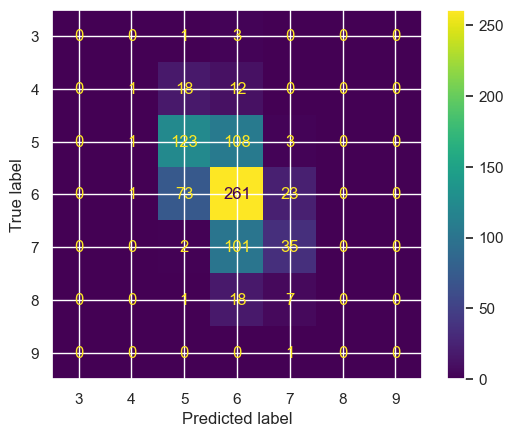

(0.5296343001261034, 0.22090084503412463)

In [91]:
fit_and_evaluate_model(model_A_white,
                       X_train_white,
                       y_train_white, 
                       X_test_white, 
                       y_test_white, 
                       dataset_name = "White Wine Dataset")

In [89]:
model_A_red = Pipeline(steps = [("preprocess", preprocess_red), ("mclf", logreg)])
model_A_red

,steps,"[('preprocess', ...), ('mclf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


 Evaluation Results: Red Wine Dataset
Accuracy: 0.5809
Macro F1-Score: 0.2676

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272



<Figure size 640x480 with 0 Axes>

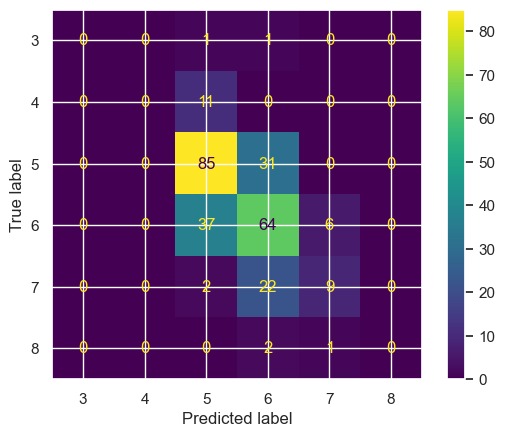

(0.5808823529411765, 0.267637794226844)

In [92]:
fit_and_evaluate_model(model_A_red,
                       X_train_red,
                       y_train_red, 
                       X_test_red, 
                       y_test_red, 
                       dataset_name = "Red Wine Dataset")

**Which dataset performed better for Logistic Regression?**

The Red Wine dataset performed better in terms of accuracy, precsion  and recall compared to the white wine dataset.

**Which quality class looks hardest (lowest recall)?**

The classes 3,4,8 have the lowest recall for Red wine dataset and 3,4,9 for the white wine dataset.

<h2>Task 5 — Model B (Tree Model): Random Forest (Red vs White)</h2>

**Instructions**
Train Model B on both datasets:
- RandomForestClassifier(n_estimators=300, random_state=42)

Evaluate using the same metrics as Task 4:
- Accuracy
- Confusion Matrix
- Classification Report
- Macro F1-score

Deliverables
- Results for red + results for white
- 4–6 lines answering:
- Did Random Forest improve compared to Logistic Regression?
- Which class is still hardest?

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
model_B_white = RandomForestClassifier(n_estimators = 300, random_state = 42)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


 Evaluation Results: White Wine Dataset
Accuracy: 0.5712
Macro F1-Score: 0.2791

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.62      0.16      0.26        31
           5       0.61      0.60      0.60       235
           6       0.56      0.74      0.64       358
           7       0.53      0.30      0.39       138
           8       0.50      0.04      0.07        26
           9       0.00      0.00      0.00         1

    accuracy                           0.57       793
   macro avg       0.40      0.26      0.28       793
weighted avg       0.57      0.57      0.55       793



<Figure size 640x480 with 0 Axes>

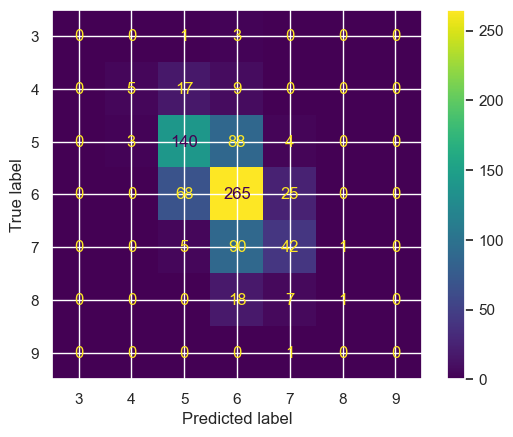

(0.5712484237074401, 0.27908282448168037)

In [93]:
fit_and_evaluate_model(model_B_white,
                       X_train_white,
                       y_train_white, 
                       X_test_white, 
                       y_test_white, 
                       dataset_name = "White Wine Dataset")

In [61]:
model_B_red = RandomForestClassifier(n_estimators = 300, random_state = 42)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


 Evaluation Results: Red Wine Dataset
Accuracy: 0.6213
Macro F1-Score: 0.2922

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.73      0.71       116
           6       0.58      0.68      0.63       107
           7       0.55      0.33      0.42        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.29      0.29       272
weighted avg       0.59      0.62      0.60       272



<Figure size 640x480 with 0 Axes>

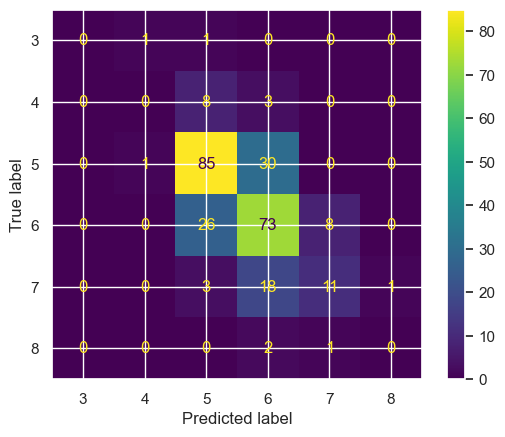

(0.6213235294117647, 0.2921668088020724)

In [94]:
fit_and_evaluate_model(model_B_red,
                       X_train_red,
                       y_train_red, 
                       X_test_red, 
                       y_test_red, 
                       dataset_name = "Red Wine Dataset")

**Did Random Forest improve compared to Logistic Regression?**

Yes, Random Forest improved overall performance compared to Logistic Regression across both datasets. For White Wine, accuracy increased from ~54% to 57.12% and Macro F1 improved from ~0.21 to 0.2791; for Red Wine, accuracy increased from 58.09% to 62.13% and Macro F1 rose from 0.2676 to 0.2922. The ensemble of decision trees better captured complex, non-linear relationships between chemical properties than linear decision boundaries.

**Which class is still hardest?**

The extreme minority classes remain the hardest to predict, specifically classes 3 and 9 (0.00 recall/F1-score), followed by classes 4 and 8 (very low recall). Despite Random Forest's overall gains, severe class imbalance leaves these rare quality ratings with insufficient training instances, causing the model to almost always misclassify them into the dominant middle classes (5 and 6).

<h2>Task 6 — Comparative Metrics Summary(Core Comparative Study Output)</h2>

**Instructions**
Create a clean summary for all four experiments using only:
- Accuracy
- Confusion Matrix
- Classification Report
- F1-score
Required comparison table
|Dataset|       Model       | Accuracy | F1-score| Key Observation (1 line)|
|:-----:|:-----------------:|:--------:|:-------:|:-----------------------:|
|  Red  |Logistic Regression|
|  Red  |   Random Forest   |
| White |Logistic Regression|
| White |   Random Forest   |

**Required supporting outputs**

For each of the four experiments, include:
- Confusion matrix
- Classification report

**Deliverables**
- Completed table
- All four confusion matrices
- All four classification reports
- 4–6 lines summarizing: best dataset + best model + reason

In [98]:
summary_data = {
    "Dataset": ["Red", "Red", "White", "White"],
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest",
    ],
    "Accuracy": ["58.09%", "62.13%", "52.96%", "57.12%"],
    "Macro F1-score": [0.2676, 0.2922, 0.2209, 0.2791],
    "Key Observation (1 line)": [
        "Linear baseline struggles to predict rare classes (3, 4, 8) with zero recall.",
        "Captures non-linear feature interactions, yielding higher overall accuracy.",
        "Linear boundary struggles to differentiate dominant middle quality classes.",
        "Highest overall accuracy and macro F1 score across all experiments.",
    ],
}
df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Dataset,Model,Accuracy,Macro F1-score,Key Observation (1 line)
0,Red,Logistic Regression,58.09%,0.2676,Linear baseline struggles to predict rare clas...
1,Red,Random Forest,62.13%,0.2922,"Captures non-linear feature interactions, yiel..."
2,White,Logistic Regression,52.96%,0.2209,Linear boundary struggles to differentiate dom...
3,White,Random Forest,57.12%,0.2791,Highest overall accuracy and macro F1 score ac...


 Evaluation Results: Red Wine (Logistic Regression)
Accuracy: 0.5809
Macro F1-Score: 0.2676

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272



<Figure size 640x480 with 0 Axes>

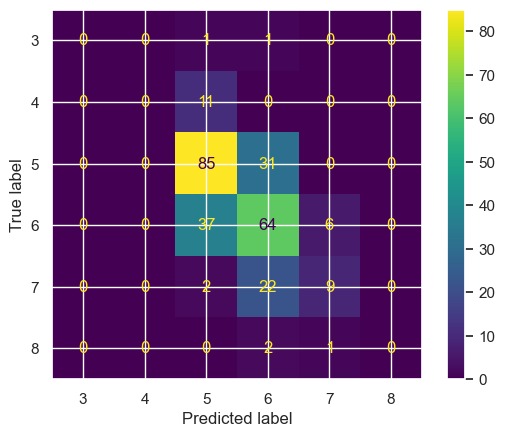

 Evaluation Results: Red Wine (Random Forest)
Accuracy: 0.6213
Macro F1-Score: 0.2922

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.73      0.71       116
           6       0.58      0.68      0.63       107
           7       0.55      0.33      0.42        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.29      0.29       272
weighted avg       0.59      0.62      0.60       272



<Figure size 640x480 with 0 Axes>

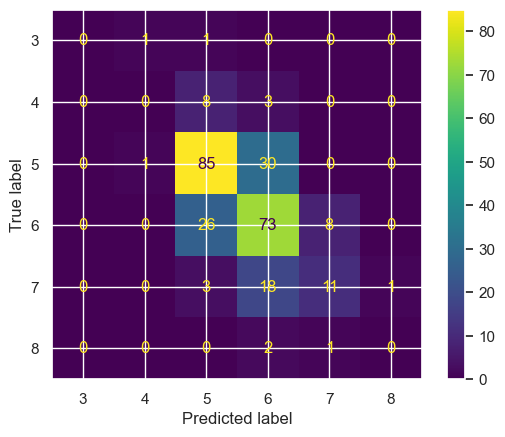

 Evaluation Results: White Wine (Logistic Regression)
Accuracy: 0.5296
Macro F1-Score: 0.2209

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.33      0.03      0.06        31
           5       0.56      0.52      0.54       235
           6       0.52      0.73      0.61       358
           7       0.51      0.25      0.34       138
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00         1

    accuracy                           0.53       793
   macro avg       0.27      0.22      0.22       793
weighted avg       0.50      0.53      0.50       793



<Figure size 640x480 with 0 Axes>

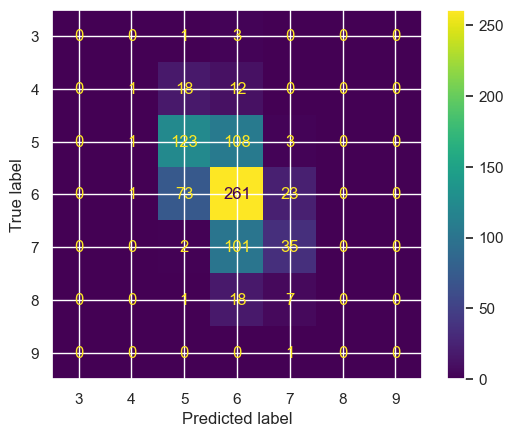

 Evaluation Results: White Wine (Random Forest)
Accuracy: 0.5712
Macro F1-Score: 0.2791

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.62      0.16      0.26        31
           5       0.61      0.60      0.60       235
           6       0.56      0.74      0.64       358
           7       0.53      0.30      0.39       138
           8       0.50      0.04      0.07        26
           9       0.00      0.00      0.00         1

    accuracy                           0.57       793
   macro avg       0.40      0.26      0.28       793
weighted avg       0.57      0.57      0.55       793



<Figure size 640x480 with 0 Axes>

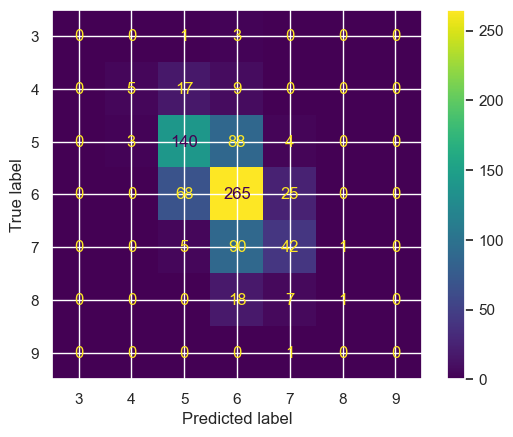

(0.5712484237074401, 0.27908282448168037)

In [97]:
# 1. Red Wine - Logistic Regression
fit_and_evaluate_model(
    model_A_red,
    X_train_red,
    y_train_red,
    X_test_red,
    y_test_red,
    "Red Wine (Logistic Regression)",
)

# 2. Red Wine - Random Forest
fit_and_evaluate_model(
    model_B_red,
    X_train_red,
    y_train_red,
    X_test_red,
    y_test_red,
    "Red Wine (Random Forest)",
)

# 3. White Wine - Logistic Regression
fit_and_evaluate_model(
    model_A_white,
    X_train_white,
    y_train_white,
    X_test_white,
    y_test_white,
    "White Wine (Logistic Regression)",
)

# 4. White Wine - Random Forest
fit_and_evaluate_model(
    model_B_white,
    X_train_white,
    y_train_white,
    X_test_white,
    y_test_white,
    "White Wine (Random Forest)",
)

The Red Wine dataset paired with Random Forest achieved the best overall performance, achieving the highest accuracy of 62.13% and Macro F1-score of 0.2922 across all evaluated pipelines. The Red Wine dataset proved easier to predict than White Wine (57.12% Random Forest accuracy) because it contains fewer total target classes (6 classes vs. 7 classes) and a less fragmented distribution among middle quality ratings. Random Forest consistently outperformed Logistic Regression across both datasets because decision tree ensembles naturally capture non-linear feature relationships and non-monotonic decision boundaries, whereas linear models struggle with complex chemical interactions. However, severe class imbalance remained a persistent issue, as extreme minority classes (3, 4, 8, and 9) still suffered from low sample sizes and near-zero recall.

<h2>Task 7 — Final Conclusion (Comparative Summary)</h2>

Write a final paragraph (10–12 lines) answering:
1. Which dataset was easier to predict (red or white) and why?
2. Which model performed better overall and why?
3. Which quality classes were most confusing and why?
4. What ONE improvement would you try next (choose one):
    - class_weight="balanced"
    - convert to 3 classes (Low/Med/High)
    - hyperparameter tuning
    - feature engineering

Deliverables
- Final conclusion paragraph

Across all experiments, the Red Wine dataset proved easier to predict than White Wine, achieving higher overall accuracy (62.13% vs. 57.12% with Random Forest) because it has fewer distinct target classes (6 vs. 7) and a less fragmented distribution among middle-tier quality ratings. Overall, Random Forest performed significantly better than Logistic Regression across both datasets because tree-based ensembles effectively capture complex, non-linear relationships and interactions among chemical attributes that linear decision boundaries cannot separate. The most confusing quality classes were the extreme minority labels ( classes 3, 4, 8, and 9), along with subtle boundaries between adjacent middle classes (ratings 5 vs. 6), primarily because human subjective evaluations create overlapping feature distributions and severe class imbalance leaves minority classes with insufficient training samples. To address these issues next, I would convert the target into 3 broader classes (Low, Medium, High). This approach eliminates the fine-grained ambiguity inherent in subjective rating scales, balances sample distribution across tiers, and aligns closer with practical quality assessment goals.